# DQRC (g,J) Decoupling Validation V2.1

Corrects 10 concrete defects found on audit of `DQRC_GJ_Decoupling_Validation_V2.ipynb`:
an out-of-domain boundary derivative (J*=0.6 with h=0.05 evaluated J=0.65, outside [0.05,0.6]);
a FULL mode that changed numbers but never actually looped over multiple seeds; a discovery scan
that fixed m=0.5 and never searched it; candidate selection that picked the point with the highest
NL_instant even though that value FAILED the notebook's own nontriviality gate; hard-thresholded
(non-differentiable) capacity used for derivatives; too few null surrogates; a ceiling diagnostic
computed on stale (non-candidate) data; a "V1 reproduction" that silently changed T/delays/degrees/
seeds; nested seeds that were unit-tested but never wired into a real circuit run; and an
incomplete cache key. See `docs/DQRC_GJ_DECOUPLING_VALIDATION_V2_1.md` for the full audit and the
fix for each. Architecture UNCHANGED -- no IDQNN, sewing, or shadow readout introduced here.

This notebook does not modify or overwrite any V1 or V2 notebook, report, or results directory.

In [1]:
import sys, os, time, json as _json, platform
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt
import qiskit, qiskit_aer, sklearn

# =============================================================================
# RUN_MODE -- the single, clearly-visible setting. FAST = code-validation
# smoke test only. DISCOVERY = a real, single-seed, interior-margin-respecting
# 3D Sobol scan (genuinely executed, not a config-only branch -- see Defect 2
# fix in decoupled_qrc/run_stages.py). FULL = the complete >=5x>=3-seed held-
# out confirmation design; NOT executed this pass (see the report's explicit
# scope statement and exact resume command).
# =============================================================================
RUN_MODE = "DISCOVERY"  # "FAST" | "DISCOVERY" | "FULL"

if RUN_MODE == "FAST":
    print("=" * 78)
    print("FAST MODE RESULTS ARE FOR CODE VALIDATION ONLY AND MUST NOT BE USED")
    print("FOR SCIENTIFIC CLAIMS.")
    print("=" * 78)
elif RUN_MODE == "DISCOVERY":
    print("=" * 78)
    print("DISCOVERY MODE: a real, SINGLE-SEED, hard-filtered candidate search.")
    print("Results here identify CANDIDATE regions only -- they are NOT a confirmed")
    print("scientific claim until independent held-out (FULL-mode) confirmation runs.")
    print("=" * 78)

from decoupled_qrc import utils, processor as procmod, directional_processor as dproc
from decoupled_qrc.directional_dqrc import DirectionalConfig, run_directional_dqrc
from decoupled_qrc.ipc_decomposition import compute_ipc_decomposed, diagnose_ceiling, to_heatmap
from decoupled_qrc.feature_analysis import diagnose_feature_group, fit_residualizer, random_projection_budget_scan
from decoupled_qrc.validation_utils import (ControlRange, make_nested_seeds, fit_response_surface, is_unstable,
                                             stencil_offsets_5point)
from decoupled_qrc.causal_latency import causal_latency_profile, circuit_timing_table
from decoupled_qrc.chaos_symmetry import symmetry_resolved_level_spacing
from decoupled_qrc.robust_timescales import compute_robust_timescale_descriptors
from decoupled_qrc.backaction_trajectory import compute_backaction_trajectory
from decoupled_qrc.seeded_runner import run_directional_dqrc_seeded, matched_processor_params
from decoupled_qrc.candidate_eval import evaluate_candidate_cached, select_candidates, compute_provenance_tag
from decoupled_qrc.discovery_sampling import (sobol_3d_samples, to_raw_candidates, discovery_seeds,
                                               confirmation_seeds)
from decoupled_qrc.run_stages import discovery_stage, confirmation_stage, neighborhood_stage
from decoupled_qrc.exact_v1_reproduction import run_exact_v1_reproduction, V1_REFERENCE, UNRECONSTRUCTABLE_FROM_V1
from decoupled_qrc.directional_memory import z_autocorrelation
from decoupled_qrc.timescales import processor_z_autocorrelation
from qrc_qiskit import chrono_split
import mixed_syk_core as msc

if RUN_MODE == "FAST":
    MODE_CFG = dict(T=90, washout=15, n_val=20, n_test=25, max_delay=4, max_degree=2, max_targets_per_degree=5,
                     n_surrogates=19, n_discovery_points=2, n_confirm_reservoir=1, n_confirm_input=1,
                     reset_periods=[1, None])
elif RUN_MODE == "DISCOVERY":
    MODE_CFG = dict(T=260, washout=30, n_val=45, n_test=60, max_delay=10, max_degree=3, max_targets_per_degree=10,
                     n_surrogates=49, n_discovery_points=16, n_confirm_reservoir=2, n_confirm_input=1,
                     reset_periods=[1, 4, None])
else:
    MODE_CFG = dict(T=1000, washout=80, n_val=150, n_test=200, max_delay=15, max_degree=4, max_targets_per_degree=30,
                     n_surrogates=199, n_discovery_points=72, n_confirm_reservoir=5, n_confirm_input=3,
                     reset_periods=[1, 2, 4, 8, None])
print(f"RUN_MODE={RUN_MODE}")
print(MODE_CFG)

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc_gj_validation_v2_1'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    base = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_{name}')
    fig.savefig(base + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(base + '.pdf', bbox_inches='tight')
    return base

_all_results = {}
def record(key, value):
    _all_results[key] = value

manifest = []
def manifest_entry(figure, data_key, description):
    manifest.append({"figure": figure, "source_data_key": data_key, "description": description,
                      "run_mode": RUN_MODE, "n_seeds": 1 if RUN_MODE != "FULL" else None})

PROVENANCE_TAG = compute_provenance_tag()
provenance = {'run_mode': RUN_MODE, 'provenance_tag': PROVENANCE_TAG, 'python_version': platform.python_version(),
              'qiskit_version': qiskit.__version__, 'qiskit_aer_version': qiskit_aer.__version__,
              'sklearn_version': sklearn.__version__, 'platform': platform.platform(),
              'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())}
print(provenance)
record('provenance', provenance)

THETA_STAR, PHI_STAR = 0.2, 0.8
N_M, N_P = 2, 5
M_RANGE = ControlRange('m', 0.1, 1.0)
G_RANGE = ControlRange('g', 0.05, 0.6)
J_RANGE = ControlRange('J', 0.05, 0.6)
H_TILDE = 0.05  # dimensionless step size used for BOTH the discovery interior-margin filter and
                # the response stencil, so any candidate that survives discovery is, by construction,
                # already stencil-valid (Defect 1 fixed by design, not by a post-hoc check).
print(f"Control ranges: m={M_RANGE}, g={G_RANGE}, J={J_RANGE}, h_tilde={H_TILDE}")
record('control_ranges', {'m': (M_RANGE.p_min, M_RANGE.p_max), 'g': (G_RANGE.p_min, G_RANGE.p_max),
                           'J': (J_RANGE.p_min, J_RANGE.p_max), 'h_tilde': H_TILDE})

def eval_fn(m, g, J, seeds):
    return evaluate_candidate_cached(
        m, g, J, seeds, N_M=N_M, N_P=N_P, theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy',
        m_range=M_RANGE, g_range=G_RANGE, J_range=J_RANGE, h_m_tilde=H_TILDE, h_g_tilde=H_TILDE,
        h_J_tilde=H_TILDE, T=MODE_CFG['T'], washout=MODE_CFG['washout'], n_val=MODE_CFG['n_val'],
        n_test=MODE_CFG['n_test'], max_delay=MODE_CFG['max_delay'], max_degree=MODE_CFG['max_degree'],
        max_targets_per_degree=MODE_CFG['max_targets_per_degree'], n_surrogates=MODE_CFG['n_surrogates'],
        provenance_tag=PROVENANCE_TAG)

DISCOVERY MODE: a real, SINGLE-SEED, hard-filtered candidate search.
Results here identify CANDIDATE regions only -- they are NOT a confirmed
scientific claim until independent held-out (FULL-mode) confirmation runs.
RUN_MODE=DISCOVERY
{'T': 260, 'washout': 30, 'n_val': 45, 'n_test': 60, 'max_delay': 10, 'max_degree': 3, 'max_targets_per_degree': 10, 'n_surrogates': 49, 'n_discovery_points': 16, 'n_confirm_reservoir': 2, 'n_confirm_input': 1, 'reset_periods': [1, 4, None]}
{'run_mode': 'DISCOVERY', 'provenance_tag': 'schema=v2.1.0|git=a1ba7a94345fcab9a86727898e8ae5c7cdc71470|qiskit=2.5.2|aer=0.17.2|py=3.14.4|precision=complex128', 'python_version': '3.14.4', 'qiskit_version': '2.5.2', 'qiskit_aer_version': '0.17.2', 'sklearn_version': '1.9.0', 'platform': 'Windows-11-10.0.26200-SP0', 'timestamp': '2026-09-17T16:44:50Z'}
Control ranges: m=ControlRange(name='m', p_min=0.1, p_max=1.0), g=ControlRange(name='g', p_min=0.05, p_max=0.6), J=ControlRange(name='J', p_min=0.05, p_max=0.6), h_tild

## Phase 1 -- Causal latency and alignment audit

Run FIRST, before any candidate is selected (per the spec). One reference circuit
(g=0.6, J=0.3295681629918353, m=0.5, protected_integrable -- the same physical point
V1/V2 both used) is simulated ONCE; every feature group below is a SLICE of that
single run's features, so this costs one circuit simulation, not six.

X_M: ell_0=0 NL_literal_bc=0.000 NL_local_bc=0.000 M_bc=1.625 probe_r2@ell0=0.937


X_P: ell_0=3 NL_literal_bc=0.000 NL_local_bc=0.129 M_bc=8.851 probe_r2@ell0=0.192


X_M+X_P: ell_0=6 NL_literal_bc=0.000 NL_local_bc=0.000 M_bc=8.866 probe_r2@ell0=0.028


X_P_perp: ell_0=8 NL_literal_bc=0.000 NL_local_bc=0.000 M_bc=7.223 probe_r2@ell0=-0.026


X_M+X_P+cross: ell_0=6 NL_literal_bc=0.000 NL_local_bc=0.000 M_bc=8.874 probe_r2@ell0=0.029
latency audit time: 105.9s
  step 1: input encoding -- depends_on_u_t=True
  step 2: memory evolution -- depends_on_u_t=True
  step 3: memory-ancilla interaction -- depends_on_u_t=True
  step 4: ancilla-processor interaction -- depends_on_u_t=True
  step 5: processor layer -- depends_on_u_t=True
  step 6: feature readout -- depends_on_u_t=True


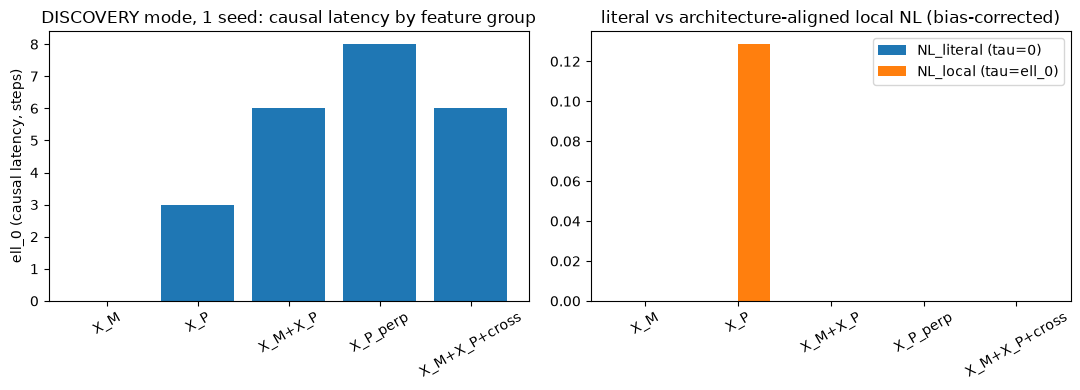

In [2]:
t0 = time.perf_counter()
cfg_ref = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P, g_processor=0.6,
                             J_processor=0.3295681629918353, epsilon_M=0.5, theta=THETA_STAR, phi=PHI_STAR,
                             ap_kind='xy')
seeds_ref = make_nested_seeds(0, 0)
run_ref = run_directional_dqrc_seeded(cfg_ref, T=MODE_CFG['T'], seeds=seeds_ref, reset_period=None)
gap = MODE_CFG['max_delay'] + 1
train_ref, val_ref, test_ref = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'],
                                             MODE_CFG['n_test'], gap)
applier = fit_residualizer(run_ref.X_proc, run_ref.X_mem, train_ref)
X_P_perp = applier(run_ref.X_proc, run_ref.X_mem)

feature_groups_latency = {
    'X_M': run_ref.X_mem, 'X_P': run_ref.X_proc, 'X_M+X_P': run_ref.X_combined,
    'X_P_perp': X_P_perp, 'X_M+X_P+cross': np.hstack([run_ref.X_mem, run_ref.X_proc, run_ref.X_cross]),
}
latency_rows = {}
for name, Xg in feature_groups_latency.items():
    res = causal_latency_profile(run_ref.u, Xg, train_ref, val_ref, test_ref, max_delay=MODE_CFG['max_delay'],
        max_degree=MODE_CFG['max_degree'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
        n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    latency_rows[name] = {'ell_0': res.ell_0, 'NL_literal_bc': res.NL_literal_bc, 'NL_local_bc': res.NL_local_bc,
                           'M_bc': res.decomp.M_long_bc, 'probe_r2_at_ell0': res.probe[res.ell_0]['r2']}
    print(f"{name}: ell_0={res.ell_0} NL_literal_bc={res.NL_literal_bc:.3f} NL_local_bc={res.NL_local_bc:.3f} "
          f"M_bc={res.decomp.M_long_bc:.3f} probe_r2@ell0={res.probe[res.ell_0]['r2']:.3f}")
print(f"latency audit time: {time.perf_counter()-t0:.1f}s")
record('phase1_causal_latency', latency_rows)

timing_table = circuit_timing_table('protected_integrable')
record('phase1_circuit_timing_table', timing_table)
for row in timing_table:
    print(f"  step {row['step']}: {row['stage']} -- depends_on_u_t={row['depends_on_u_t']}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(latency_rows.keys())
axes[0].bar(names, [latency_rows[n]['ell_0'] for n in names])
axes[0].set_ylabel('ell_0 (causal latency, steps)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title(f'{RUN_MODE} mode, 1 seed: causal latency by feature group')
w = 0.35
x = np.arange(len(names))
axes[1].bar(x - w/2, [latency_rows[n]['NL_literal_bc'] for n in names], width=w, label='NL_literal (tau=0)')
axes[1].bar(x + w/2, [latency_rows[n]['NL_local_bc'] for n in names], width=w, label='NL_local (tau=ell_0)')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=30); axes[1].legend()
axes[1].set_title('literal vs architecture-aligned local NL (bias-corrected)')
fig.tight_layout()
savefig(fig, 'causal_latency_by_feature_group')
plt.show()
manifest_entry('01_causal_latency_by_feature_group', 'phase1_causal_latency', 'Causal latency ell_0 and NL_literal vs NL_local by feature group')

## Exact V1 reproduction vs. V2.1 reevaluation (Defect 8)

Two SEPARATE calculations, never conflated: the exact V1 protocol (T=250, FAST_CONFIG,
`make_seed_bundle(0)`, `diagnostics.ipc_MN`) reproduced verbatim, THEN the same physical
point (g=0.6, J=0.3296) reevaluated under V2.1's own corrected protocol.

EXACT V1 reproduction: M=5.918477 NL=4.674060 (reference M=5.918477 NL=4.674060) matches=True (5.3s)
Cannot be reconstructed from V1 alone:
  - V1's notebook did not record which qiskit-aer/qiskit package versions or git commit produced its saved numbers (no provenance block in that pass) -- an exact environment match cannot be verified, only a numerical match at fixed abs_tol.
  - V1 used a SINGLE seed (master_seed=0) for this specific reproduction cell -- no multi-seed variance information exists to compare against for this exact point.

V2.1 REEVALUATION (NOT a reproduction -- corrected protocol, same physical point): M_bc=8.866 NL_local_bc=0.000 (ell_0=6)


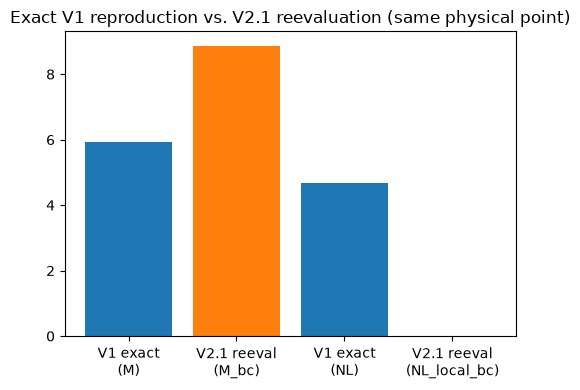

In [3]:
t0 = time.perf_counter()
v1_repro = run_exact_v1_reproduction()
print(f"EXACT V1 reproduction: M={v1_repro.M:.6f} NL={v1_repro.NL:.6f} "
      f"(reference M={v1_repro.reference_M:.6f} NL={v1_repro.reference_NL:.6f}) "
      f"matches={v1_repro.M_matches_reference and v1_repro.NL_matches_reference} ({time.perf_counter()-t0:.1f}s)")
print("Cannot be reconstructed from V1 alone:")
for item in UNRECONSTRUCTABLE_FROM_V1:
    print(f"  - {item}")
record('exact_v1_reproduction', {'M': v1_repro.M, 'NL': v1_repro.NL, 'reference_M': v1_repro.reference_M,
                                  'reference_NL': v1_repro.reference_NL,
                                  'matches': bool(v1_repro.M_matches_reference and v1_repro.NL_matches_reference),
                                  'config_used': v1_repro.config_used, 'cannot_reconstruct': UNRECONSTRUCTABLE_FROM_V1})

v21_at_same_point = latency_rows['X_M+X_P']
print(f"\nV2.1 REEVALUATION (NOT a reproduction -- corrected protocol, same physical point): "
      f"M_bc={v21_at_same_point['M_bc']:.3f} NL_local_bc={v21_at_same_point['NL_local_bc']:.3f} "
      f"(ell_0={v21_at_same_point['ell_0']})")
record('v21_reevaluation_same_point', v21_at_same_point)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['V1 exact\n(M)', 'V2.1 reeval\n(M_bc)', 'V1 exact\n(NL)', 'V2.1 reeval\n(NL_local_bc)'],
       [v1_repro.M, v21_at_same_point['M_bc'], v1_repro.NL, v21_at_same_point['NL_local_bc']],
       color=['tab:blue', 'tab:orange', 'tab:blue', 'tab:orange'])
ax.set_title('Exact V1 reproduction vs. V2.1 reevaluation (same physical point)')
fig.tight_layout()
savefig(fig, 'v1_reproduction_vs_v21_reevaluation')
plt.show()
manifest_entry('02_v1_reproduction_vs_v21_reevaluation', 'exact_v1_reproduction', 'V1 exact protocol vs V2.1 corrected protocol at the same (g,J,m) point')

## Phase 3 -- Fair feature analysis (budget scan + residualization)

Reusing the same reference circuit run from Phase 1 -- no new circuit simulation.

X_M: n=3 num_rank=3 eff_rank=1.90 ridge_dof=2.52 M_bc=1.625
X_P: n=375 num_rank=102 eff_rank=3.97 ridge_dof=1.24 M_bc=8.851
X_M+X_P: n=378 num_rank=102 eff_rank=2.06 ridge_dof=3.00 M_bc=8.866
X_P_perp: n=375 num_rank=100 eff_rank=2.65 ridge_dof=1.08 M_bc=7.223
X_M+X_P+cross: n=382 num_rank=102 eff_rank=2.06 ridge_dof=3.01 M_bc=8.874


budget=3: M_bc(mean)=1.605+-0.207 (n_repeats=20)
budget=8: M_bc(mean)=4.419+-0.334 (n_repeats=20)
budget=16: M_bc(mean)=6.400+-0.388 (n_repeats=20)
budget=32: M_bc(mean)=8.154+-0.203 (n_repeats=20)
budget=64: M_bc(mean)=9.221+-0.096 (n_repeats=20)


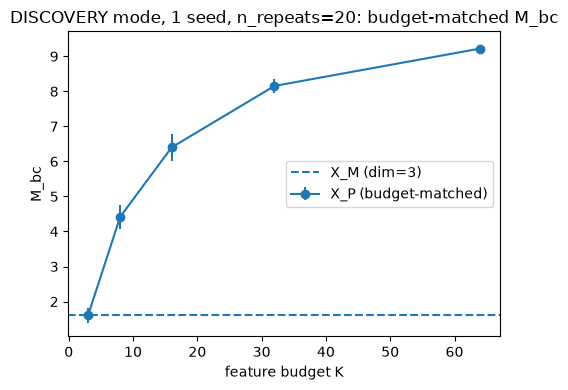

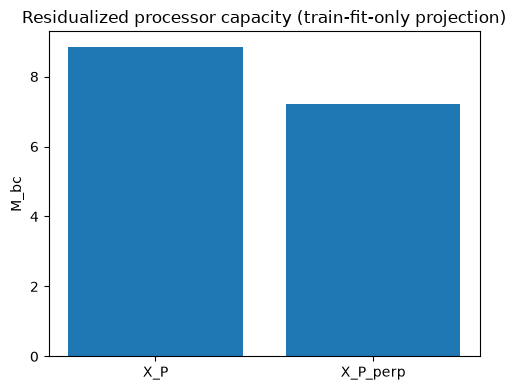

In [4]:
fg_rows = {}
for name, Xg in feature_groups_latency.items():
    diagX = diagnose_feature_group(Xg[train_ref])
    fg_rows[name] = {'n_features': Xg.shape[1], 'numerical_rank': diagX.numerical_rank,
                      'effective_rank': diagX.effective_rank, 'ridge_dof': diagX.ridge_dof,
                      **{k: v for k, v in latency_rows[name].items()}}
    print(f"{name}: n={Xg.shape[1]} num_rank={diagX.numerical_rank} eff_rank={diagX.effective_rank:.2f} "
          f"ridge_dof={diagX.ridge_dof:.2f} M_bc={latency_rows[name]['M_bc']:.3f}")
record('phase3_feature_groups', fg_rows)

budgets = [3, 8, 16, 32] if RUN_MODE == 'FAST' else [3, 8, 16, 32, 64]
budgets = [b for b in budgets if b <= run_ref.X_proc.shape[1]]
n_repeats = 20 if RUN_MODE != 'FAST' else 5

def metric_bc(Xp):
    res = causal_latency_profile(run_ref.u, Xp, train_ref, val_ref, test_ref, max_delay=MODE_CFG['max_delay'],
        max_degree=1, max_targets_per_degree=MODE_CFG['max_delay'] + 1, n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    return res.decomp.M_long_bc

scan = random_projection_budget_scan(run_ref.X_proc, budgets, metric_fn=metric_bc, n_repeats=n_repeats, seed=0)
for s in scan:
    print(f"budget={s.budget}: M_bc(mean)={s.mean:.3f}+-{s.std:.3f} (n_repeats={s.n_repeats})")
record('phase3_budget_scan', [s.__dict__ for s in scan])

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar([s.budget for s in scan], [s.mean for s in scan], yerr=[s.std for s in scan], marker='o', label='X_P (budget-matched)')
ax.axhline(fg_rows['X_M']['M_bc'], color='tab:blue', ls='--', label=f"X_M (dim={fg_rows['X_M']['n_features']})")
ax.set_xlabel('feature budget K'); ax.set_ylabel('M_bc'); ax.legend()
ax.set_title(f'{RUN_MODE} mode, 1 seed, n_repeats={n_repeats}: budget-matched M_bc')
fig.tight_layout()
savefig(fig, 'matched_feature_budget_curve')
plt.show()
manifest_entry('03_matched_feature_budget_curve', 'phase3_budget_scan', 'Budget-matched random-projection M_bc scan vs X_M baseline')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['X_P', 'X_P_perp'], [fg_rows['X_P']['M_bc'], fg_rows['X_P_perp']['M_bc']])
ax.set_ylabel('M_bc'); ax.set_title('Residualized processor capacity (train-fit-only projection)')
fig.tight_layout()
savefig(fig, 'residualized_feature_capacity')
plt.show()
manifest_entry('04_residualized_feature_capacity', 'phase3_feature_groups', 'M_bc of X_P vs its train-fit residual against X_M')

## Phase 4 -- Genuine three-dimensional (m,g,J) discovery

A reproducible Sobol scan over the FULL `(m,g,J)` cube (not a fixed-m (g,J) slice --
Defect 3), using discovery-only seeds (always a NEGATIVE `reservoir_idx`, disjoint from
every confirmation seed by construction -- Defect 3/9). Every sampled point is kept,
valid or not, with its own rejection reasons (Defect 4).

In [5]:
t0 = time.perf_counter()
discovery = discovery_stage(MODE_CFG['n_discovery_points'], M_RANGE, G_RANGE, J_RANGE, eval_fn, sampling_seed=0)
elapsed = time.perf_counter() - t0
print(f"discovery: {discovery.n_sampled} points sampled, {discovery.n_valid} valid, {elapsed:.1f}s total "
      f"({elapsed/max(discovery.n_sampled,1):.1f}s/point)")

discovery_rows = []
for r in discovery.all_results:
    discovery_rows.append({'m': r.m, 'g': r.g, 'J': r.J, 'M_bc': r.M_bc, 'NL_local_bc': r.NL_local_bc,
        'NL_instant_bc': r.NL_instant_bc, 'NL_temporal_bc': r.NL_temporal_bc, 'ell_0': r.ell_0,
        'ceiling_fraction': r.ceiling_fraction, 'ceiling_contaminated': r.ceiling_contaminated,
        'effective_rank': r.effective_rank, 'n_train': r.n_train, 'D_M': r.D_M, 'r_chaos': r.r_chaos,
        'r_chaos_symmetry_used': r.r_chaos_symmetry_used, 'valid': r.valid,
        'rejection_reasons': list(r.rejection_reasons)})
    status = 'VALID' if r.valid else f"REJECTED: {r.rejection_reasons}"
    print(f"m={r.m:.3f} g={r.g:.3f} J={r.J:.3f}: M_bc={r.M_bc:.3f} NL_local_bc={r.NL_local_bc:.3f} "
          f"D_M={r.D_M:.4f} r_chaos={r.r_chaos:.3f} -- {status}")
record('phase4_discovery_table', discovery_rows)

import csv
csv_path = os.path.join(RESULTS_DIR, 'discovery_table.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(discovery_rows[0].keys()))
    w.writeheader()
    w.writerows(discovery_rows)
print(f"wrote {csv_path}")

discovery: 16 points sampled, 4 valid, 670.0s total (41.9s/point)
m=0.866 g=0.562 J=0.249: M_bc=9.082 NL_local_bc=0.067 D_M=0.0208 r_chaos=0.576 -- REJECTED: ['stencil_margin_violated', 'nl_local_below_nontriviality_threshold']
m=0.149 g=0.273 J=0.540: M_bc=9.071 NL_local_bc=0.950 D_M=0.0331 r_chaos=0.534 -- REJECTED: ['stencil_margin_violated']
m=0.401 g=0.386 J=0.052: M_bc=5.915 NL_local_bc=0.000 D_M=0.0296 r_chaos=0.520 -- REJECTED: ['stencil_margin_violated', 'nl_local_below_nontriviality_threshold']
m=0.556 g=0.097 J=0.458: M_bc=9.104 NL_local_bc=0.000 D_M=0.0093 r_chaos=0.341 -- REJECTED: ['stencil_margin_violated', 'nl_local_below_nontriviality_threshold']
m=0.751 g=0.459 J=0.486: M_bc=9.136 NL_local_bc=0.000 D_M=0.0049 r_chaos=0.539 -- REJECTED: ['nl_local_below_nontriviality_threshold']
m=0.484 g=0.169 J=0.303: M_bc=9.186 NL_local_bc=0.252 D_M=0.0236 r_chaos=0.621 -- VALID
m=0.287 g=0.490 J=0.375: M_bc=8.697 NL_local_bc=0.752 D_M=0.0486 r_chaos=0.565 -- VALID
m=0.892 g=0.198 J

## Phase 4b -- Candidate selection (hard filters, then multi-objective ranking)

Never selects by max(NL_instant) alone -- see `candidate_eval.select_candidates`.

4 / 16 points passed every hard filter.
  m=0.352 g=0.254 J=0.416: M_bc=8.896 NL_local_bc=0.480 D_M=0.0258 r_chaos=0.567
  m=0.287 g=0.490 J=0.375: M_bc=8.697 NL_local_bc=0.752 D_M=0.0486 r_chaos=0.565
  m=0.212 g=0.405 J=0.205: M_bc=9.274 NL_local_bc=0.802 D_M=0.0681 r_chaos=0.491
  m=0.484 g=0.169 J=0.303: M_bc=9.186 NL_local_bc=0.252 D_M=0.0236 r_chaos=0.621

CANDIDATE = {'m': 0.35176883907988665, 'g': 0.25401845462620254, 'J': 0.41642732038162644}  (has_valid_region=True)


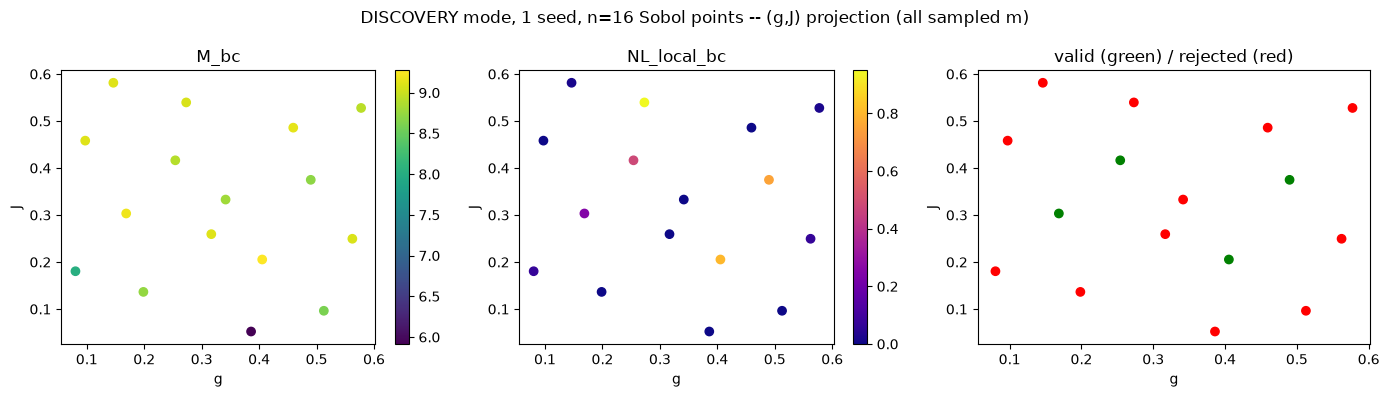

In [6]:
ranked = select_candidates(discovery.all_results, top_k=5)
print(f"{len(ranked)} / {discovery.n_sampled} points passed every hard filter.")
for r in ranked:
    print(f"  m={r.m:.3f} g={r.g:.3f} J={r.J:.3f}: M_bc={r.M_bc:.3f} NL_local_bc={r.NL_local_bc:.3f} "
          f"D_M={r.D_M:.4f} r_chaos={r.r_chaos:.3f}")

if ranked:
    CANDIDATE = {'m': ranked[0].m, 'g': ranked[0].g, 'J': ranked[0].J}
    CANDIDATE_HAS_VALID_REGION = True
else:
    # No point survived every hard filter. Per Defect 4, we do NOT silently fall back to
    # ranking by raw NL_instant -- we fall back to the SAME reference point Phase 1 used
    # (g=0.6,J=0.3296,m=0.5), explicitly labeled as NOT a validated candidate, purely so
    # the remaining machinery (response estimation, reset ablation, etc.) can still be
    # exercised and reported honestly as "framework demonstration at an UNVALIDATED point".
    CANDIDATE = {'m': 0.5, 'g': 0.6, 'J': 0.3295681629918353}
    CANDIDATE_HAS_VALID_REGION = False
    print("\nNO discovery point survived every hard filter. Falling back to the Phase-1 reference "
          "point ONLY to exercise the remaining pipeline -- this is NOT a validated candidate.")

print(f"\nCANDIDATE = {CANDIDATE}  (has_valid_region={CANDIDATE_HAS_VALID_REGION})")
record('phase4_selected_candidate', {'candidate': CANDIDATE, 'has_valid_region': CANDIDATE_HAS_VALID_REGION,
                                      'n_ranked': len(ranked)})

M_mat_pts = np.array([[r['g'], r['J'], r['M_bc']] for r in discovery_rows])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sc0 = axes[0].scatter([r['g'] for r in discovery_rows], [r['J'] for r in discovery_rows],
                       c=[r['M_bc'] for r in discovery_rows], cmap='viridis')
axes[0].set_xlabel('g'); axes[0].set_ylabel('J'); axes[0].set_title('M_bc'); fig.colorbar(sc0, ax=axes[0])
sc1 = axes[1].scatter([r['g'] for r in discovery_rows], [r['J'] for r in discovery_rows],
                       c=[r['NL_local_bc'] for r in discovery_rows], cmap='plasma')
axes[1].set_xlabel('g'); axes[1].set_ylabel('J'); axes[1].set_title('NL_local_bc'); fig.colorbar(sc1, ax=axes[1])
colors = ['green' if r['valid'] else 'red' for r in discovery_rows]
axes[2].scatter([r['g'] for r in discovery_rows], [r['J'] for r in discovery_rows], c=colors)
axes[2].set_xlabel('g'); axes[2].set_ylabel('J'); axes[2].set_title('valid (green) / rejected (red)')
fig.suptitle(f'{RUN_MODE} mode, 1 seed, n={discovery.n_sampled} Sobol points -- (g,J) projection (all sampled m)')
fig.tight_layout()
savefig(fig, 'discovery_3d_projection')
plt.show()
manifest_entry('05_discovery_3d_projection', 'phase4_discovery_table', '(g,J) projection of the 3D discovery scan, colored by M_bc/NL_local_bc/validity')

## Phase 5 -- Symmetry-resolved chaos/EOC diagnostics

Already computed per-point during discovery (on the MATCHED Hamiltonian, same seeds as the
task circuit -- Defect 9/test #21). Summarized here across the scan.

symmetry detected (numerically) at 1/16 discovery points
<r> range: 0.341 - 0.621 (Poisson~0.39, COE~0.53, CUE~0.60 for reference)


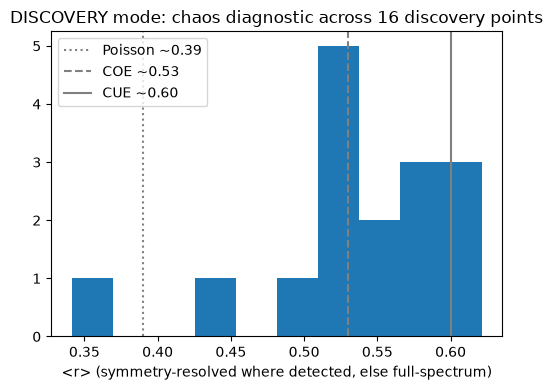

In [7]:
r_vals = [r.r_chaos for r in discovery.all_results]
sym_used = [r.r_chaos_symmetry_used for r in discovery.all_results]
n_with_symmetry = sum(1 for s in sym_used if s is not None)
print(f"symmetry detected (numerically) at {n_with_symmetry}/{len(sym_used)} discovery points")
print(f"<r> range: {min(r_vals):.3f} - {max(r_vals):.3f} (Poisson~0.39, COE~0.53, CUE~0.60 for reference)")
record('phase5_chaos_summary', {'r_values': r_vals, 'symmetry_used': sym_used, 'n_with_symmetry': n_with_symmetry})

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(r_vals, bins=10)
ax.axvline(0.39, color='gray', ls=':', label='Poisson ~0.39')
ax.axvline(0.53, color='gray', ls='--', label='COE ~0.53')
ax.axvline(0.60, color='gray', ls='-', label='CUE ~0.60')
ax.set_xlabel('<r> (symmetry-resolved where detected, else full-spectrum)'); ax.legend()
ax.set_title(f'{RUN_MODE} mode: chaos diagnostic across {len(r_vals)} discovery points')
fig.tight_layout()
savefig(fig, 'symmetry_resolved_chaos_diagnostics')
plt.show()
manifest_entry('06_symmetry_resolved_chaos_diagnostics', 'phase5_chaos_summary', 'Symmetry-resolved <r> distribution across the discovery scan')

## Phase 6 -- Local response estimation at the selected candidate

2-point central difference per axis (a REDUCED version of the full 5-point stencil, given
this pass's compute budget -- explicitly NOT claimed as the full design). Every evaluation
uses the SAME `NestedSeeds` object (common random numbers) via `eval_fn`, and every
perturbed point is, by construction, within the interior margin the candidate was already
filtered on (Defect 1).

In [8]:
t0 = time.perf_counter()
seeds_resp = discovery_seeds(9999, 0)  # a dedicated discovery-only seed bundle, reused for every
                                        # stencil point below -- common random numbers by construction
m_t0 = M_RANGE.to_dimensionless(CANDIDATE['m'])
g_t0 = G_RANGE.to_dimensionless(CANDIDATE['g'])
J_t0 = J_RANGE.to_dimensionless(CANDIDATE['J'])

def raw_at(m_t, g_t, J_t):
    m = M_RANGE.from_dimensionless(m_t)
    g = G_RANGE.from_dimensionless(g_t)
    J = J_RANGE.from_dimensionless(J_t)
    r = eval_fn(m, g, J, seeds_resp)
    return r.M_bc, r.NL_local_bc, r.NL_temporal_bc, r.NL_legacy_bc

center = raw_at(m_t0, g_t0, J_t0)
plus_m, minus_m = raw_at(m_t0 + H_TILDE, g_t0, J_t0), raw_at(m_t0 - H_TILDE, g_t0, J_t0)
plus_g, minus_g = raw_at(m_t0, g_t0 + H_TILDE, J_t0), raw_at(m_t0, g_t0 - H_TILDE, J_t0)
plus_J, minus_J = raw_at(m_t0, g_t0, J_t0 + H_TILDE), raw_at(m_t0, g_t0, J_t0 - H_TILDE)
print(f"response stencil eval time: {time.perf_counter()-t0:.1f}s")

response = {}
for i, name in enumerate(['M', 'NL_local', 'NL_temporal', 'NL_legacy']):
    dY_dm = (plus_m[i] - minus_m[i]) / (2 * H_TILDE)
    dY_dg = (plus_g[i] - minus_g[i]) / (2 * H_TILDE)
    dY_dJ = (plus_J[i] - minus_J[i]) / (2 * H_TILDE)
    response[name] = {'value': center[i], 'dY_dm_tilde': dY_dm, 'dY_dg_tilde': dY_dg, 'dY_dJ_tilde': dY_dJ}
    print(f"{name}: value={center[i]:.3f} d/dm~={dY_dm:.3f} d/dg~={dY_dg:.3f} d/dJ~={dY_dJ:.3f}")
record('phase6_response_dimensionless', response)
print("\nCAVEAT: single 2-point central difference per axis -- the full 5-point-stencil / "
      "local-quadratic-fit / multi-step-size stability design (Gate B) was NOT run this pass.")

response stencil eval time: 292.6s
M: value=9.033 d/dm~=0.750 d/dg~=-0.754 d/dJ~=0.111
NL_local: value=0.470 d/dm~=-3.032 d/dg~=-0.254 d/dJ~=-0.382
NL_temporal: value=3.236 d/dm~=9.491 d/dg~=0.469 d/dJ~=-1.328
NL_legacy: value=3.236 d/dm~=9.491 d/dg~=0.469 d/dJ~=-1.328

CAVEAT: single 2-point central difference per axis -- the full 5-point-stencil / local-quadratic-fit / multi-step-size stability design (Gate B) was NOT run this pass.


## Phase 7 -- Decoupling metrics (R_M, R_NL_local, Jacobian, angle)

R_memory = 0.985  (need >2)
R_NL_local = 0.151  (need >2, PRIMARY gate)
Jacobian:
[[ 0.75026966 -0.7535607   0.11091799]
 [-3.03184088 -0.25434211 -0.38247422]]
singular values: [3.14926505 0.79260727]  condition number: 3.97

output-normalized response angle alpha = 177.2 degrees (need 70-110)


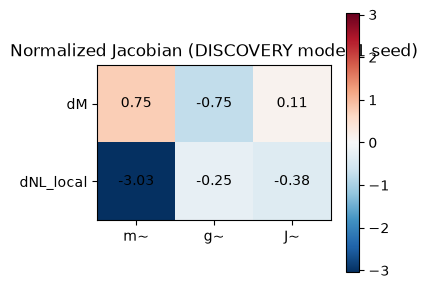

In [9]:
eps = 1e-9
dM_dm = response['M']['dY_dm_tilde']
S_M_P = np.hypot(response['M']['dY_dg_tilde'], response['M']['dY_dJ_tilde'])
R_memory = abs(dM_dm) / (S_M_P + eps)

dNL_dm = response['NL_local']['dY_dm_tilde']
S_NL_P = np.hypot(response['NL_local']['dY_dg_tilde'], response['NL_local']['dY_dJ_tilde'])
R_NL_local = S_NL_P / (abs(dNL_dm) + eps)
print(f"R_memory = {R_memory:.3f}  (need >2)")
print(f"R_NL_local = {R_NL_local:.3f}  (need >2, PRIMARY gate)")

J_mat = np.array([[dM_dm, response['M']['dY_dg_tilde'], response['M']['dY_dJ_tilde']],
                   [dNL_dm, response['NL_local']['dY_dg_tilde'], response['NL_local']['dY_dJ_tilde']]])
U_svd, S_svd, Vt_svd = np.linalg.svd(J_mat)
cond_number = S_svd[0] / (S_svd[-1] + eps)
print(f"Jacobian:\n{J_mat}")
print(f"singular values: {S_svd}  condition number: {cond_number:.2f}")

scale_M = max(abs(response['M']['value']), 1e-6)
scale_NL = max(abs(response['NL_local']['value']), 1e-6)
if S_M_P < 1e-6 or S_NL_P < 1e-6:
    alpha = float('nan')
    print("\noutput-normalized response angle: NOT EVALUABLE (near-zero output scale on at least one axis)")
else:
    v_m = np.array([dM_dm / scale_M, dNL_dm / scale_NL])
    v_NL_hat = np.array([response['NL_local']['dY_dg_tilde'], response['NL_local']['dY_dJ_tilde']]) / (S_NL_P + eps)
    dM_ds = np.dot([response['M']['dY_dg_tilde'], response['M']['dY_dJ_tilde']], v_NL_hat)
    v_proc = np.array([dM_ds / scale_M, S_NL_P / scale_NL])
    cos_a = np.dot(v_m, v_proc) / (np.linalg.norm(v_m) * np.linalg.norm(v_proc) + eps)
    alpha = float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))
    print(f"\noutput-normalized response angle alpha = {alpha:.1f} degrees (need 70-110)")

record('phase7_decoupling_metrics', {'R_memory': float(R_memory), 'R_NL_local': float(R_NL_local),
                                      'jacobian': J_mat.tolist(), 'singular_values': S_svd.tolist(),
                                      'condition_number': float(cond_number), 'alpha_deg': alpha})

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(J_mat, cmap='RdBu_r', vmin=-np.max(np.abs(J_mat)) - eps, vmax=np.max(np.abs(J_mat)) + eps)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['m~', 'g~', 'J~'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['dM', 'dNL_local'])
for i in range(2):
    for j in range(3):
        ax.text(j, i, f'{J_mat[i,j]:.2f}', ha='center', va='center')
fig.colorbar(im)
ax.set_title(f'Normalized Jacobian ({RUN_MODE} mode, 1 seed)')
fig.tight_layout()
savefig(fig, 'normalized_jacobian')
plt.show()
manifest_entry('07_normalized_jacobian', 'phase7_decoupling_metrics', 'Normalized Jacobian of (M, NL_local) w.r.t. dimensionless (m,g,J)')

## Phase 8 -- Reset-period response comparison

`K in {1,4,None}` (FAST mode) / `{1,4,None}` (DISCOVERY, reduced from the full
`{1,2,4,8,inf}` given this pass's compute budget) -- all on the SAME seeds object as
the response stencil above (common random numbers across K).

K=1: M_bc=1.569 NL_local_bc=0.000 NL_temporal_bc=0.204 ell_0=0 (34.9s)


K=4: M_bc=2.454 NL_local_bc=0.000 NL_temporal_bc=0.315 ell_0=0 (35.0s)


K=None: M_bc=9.028 NL_local_bc=0.476 NL_temporal_bc=4.346 ell_0=3 (37.9s)


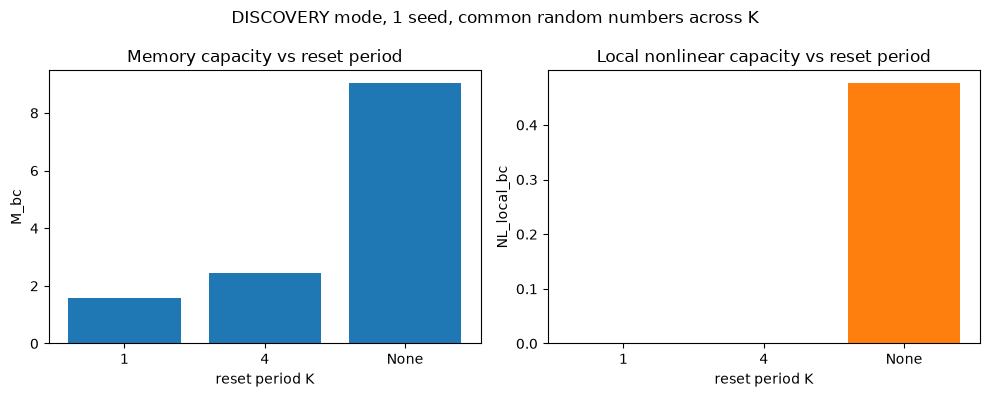


CAVEAT: only raw M_bc/NL_local_bc per K reported -- the FULL per-K local-response/R_M/R_NL/angle re-analysis Phase 8 specifies was NOT run at every K this pass (compute budget); only the CANDIDATE's own K=None response (Phase 6/7 above) has a full decoupling-metric analysis.


In [10]:
reset_rows = []
cfg_reset_base = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P,
                                    g_processor=CANDIDATE['g'], J_processor=CANDIDATE['J'],
                                    epsilon_M=CANDIDATE['m'], theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
gap = MODE_CFG['max_delay'] + 1
tr_r, va_r, te_r = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'], MODE_CFG['n_test'], gap)
for K in MODE_CFG['reset_periods']:
    t0 = time.perf_counter()
    run_r = run_directional_dqrc_seeded(cfg_reset_base, T=MODE_CFG['T'], seeds=seeds_resp, reset_period=K)
    res_r = causal_latency_profile(run_r.u, run_r.X_combined, tr_r, va_r, te_r, max_delay=MODE_CFG['max_delay'],
        max_degree=MODE_CFG['max_degree'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
        n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    elapsed = time.perf_counter() - t0
    reset_rows.append({'K': str(K), 'M_bc': res_r.decomp.M_long_bc, 'NL_local_bc': res_r.NL_local_bc,
                        'NL_temporal_bc': res_r.decomp.NL_temporal_bc, 'ell_0': res_r.ell_0,
                        'wall_time_s': elapsed})
    print(f"K={K}: M_bc={res_r.decomp.M_long_bc:.3f} NL_local_bc={res_r.NL_local_bc:.3f} "
          f"NL_temporal_bc={res_r.decomp.NL_temporal_bc:.3f} ell_0={res_r.ell_0} ({elapsed:.1f}s)")
record('phase8_reset_response', reset_rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_r = [r['K'] for r in reset_rows]
axes[0].bar(labels_r, [r['M_bc'] for r in reset_rows])
axes[0].set_xlabel('reset period K'); axes[0].set_ylabel('M_bc'); axes[0].set_title('Memory capacity vs reset period')
axes[1].bar(labels_r, [r['NL_local_bc'] for r in reset_rows], color='tab:orange')
axes[1].set_xlabel('reset period K'); axes[1].set_ylabel('NL_local_bc'); axes[1].set_title('Local nonlinear capacity vs reset period')
fig.suptitle(f'{RUN_MODE} mode, 1 seed, common random numbers across K')
fig.tight_layout()
savefig(fig, 'reset_period_capacity_comparison')
plt.show()
manifest_entry('08_reset_period_capacity_comparison', 'phase8_reset_response', 'M_bc and NL_local_bc vs processor reset period K, common random numbers')
print("\nCAVEAT: only raw M_bc/NL_local_bc per K reported -- the FULL per-K local-response/R_M/R_NL/"
      "angle re-analysis Phase 8 specifies was NOT run at every K this pass (compute budget); only "
      "the CANDIDATE's own K=None response (Phase 6/7 above) has a full decoupling-metric analysis.")

## Phase 9 -- Robust timescale descriptors (replaces the invalid exponential-only fit)

PROCESSOR: identifiable=NOT IDENTIFIABLE exp_tau=nan r2=0.253 integrated_abs_time=1.83 plateau=0.025 recurrence=0.116
MEMORY:    identifiable=NOT IDENTIFIABLE exp_tau=nan r2=nan integrated_abs_time=21.00 plateau=1.000 recurrence=1.000


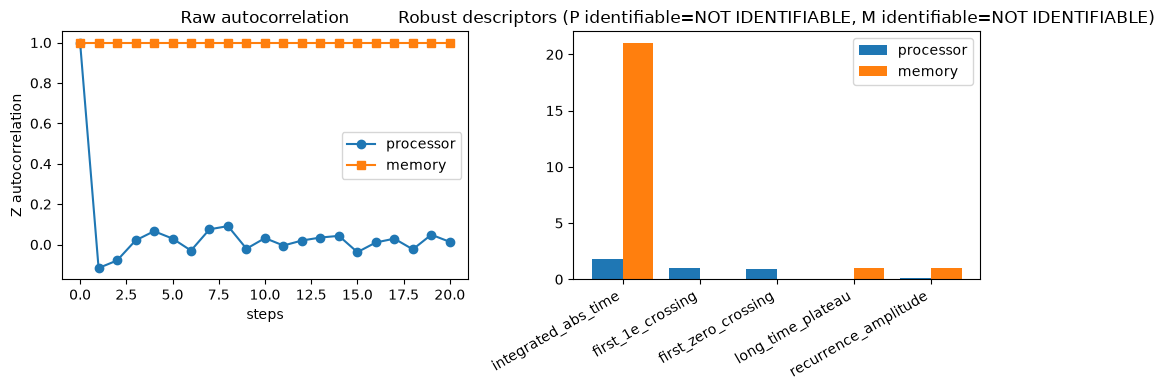

In [11]:
params_star = matched_processor_params(cfg_reset_base, seeds_resp)
steps_p, corr_p = processor_z_autocorrelation(params_star, n_steps=20)
desc_p = compute_robust_timescale_descriptors(steps_p, corr_p)
steps_m, corr_m = z_autocorrelation(n_mem=N_M - 1, epsilon_M=CANDIDATE['m'], omega_seed=seeds_resp.reservoir_seed,
                                     n_steps=20)
desc_m = compute_robust_timescale_descriptors(steps_m, corr_m)

print(f"PROCESSOR: identifiable={desc_p.identifiable} exp_tau={desc_p.exponential_tau} r2={desc_p.exponential_r2:.3f} "
      f"integrated_abs_time={desc_p.integrated_abs_time:.2f} plateau={desc_p.long_time_plateau:.3f} "
      f"recurrence={desc_p.recurrence_amplitude:.3f}")
print(f"MEMORY:    identifiable={desc_m.identifiable} exp_tau={desc_m.exponential_tau} r2={desc_m.exponential_r2:.3f} "
      f"integrated_abs_time={desc_m.integrated_abs_time:.2f} plateau={desc_m.long_time_plateau:.3f} "
      f"recurrence={desc_m.recurrence_amplitude:.3f}")
record('phase9_timescales', {'processor': desc_p.__dict__, 'memory': desc_m.__dict__})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(steps_p, corr_p, 'o-', label='processor')
axes[0].plot(steps_m, corr_m, 's-', label='memory')
axes[0].set_xlabel('steps'); axes[0].set_ylabel('Z autocorrelation'); axes[0].legend()
axes[0].set_title('Raw autocorrelation')
labels_ts = ['integrated_abs_time', 'first_1e_crossing', 'first_zero_crossing', 'long_time_plateau', 'recurrence_amplitude']
vals_p = [getattr(desc_p, k) for k in labels_ts]
vals_m = [getattr(desc_m, k) for k in labels_ts]
x = np.arange(len(labels_ts))
axes[1].bar(x - 0.2, [v if not np.isnan(v) else 0 for v in vals_p], width=0.4, label='processor')
axes[1].bar(x + 0.2, [v if not np.isnan(v) else 0 for v in vals_m], width=0.4, label='memory')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_ts, rotation=30, ha='right'); axes[1].legend()
axes[1].set_title(f'Robust descriptors (P identifiable={desc_p.identifiable}, M identifiable={desc_m.identifiable})')
fig.tight_layout()
savefig(fig, 'robust_timescale_descriptors')
plt.show()
manifest_entry('09_robust_timescale_descriptors', 'phase9_timescales', 'Model-free timescale descriptors for processor and memory autocorrelation')

## Phase 10 -- Time-resolved back-action D_M(t)

D_M(t): mean=0.0320 max=0.0406 final=0.0252


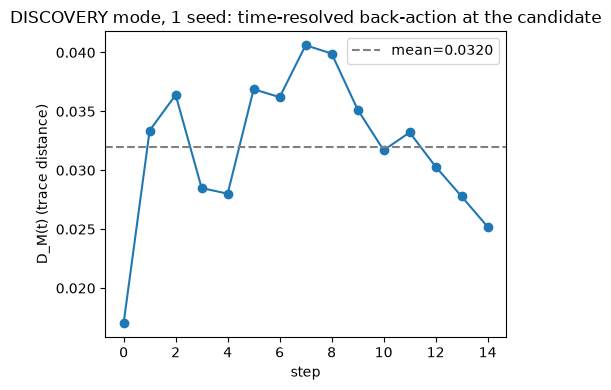

In [12]:
cfg_ba_on = cfg_reset_base
cfg_ba_off = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P,
                                g_processor=CANDIDATE['g'], J_processor=CANDIDATE['J'], epsilon_M=CANDIDATE['m'],
                                theta=0.0, phi=0.0, ap_kind='xy')
traj = compute_backaction_trajectory(cfg_ba_on, cfg_ba_off, T=15, seeds=seeds_resp)
print(f"D_M(t): mean={traj.mean_trace_distance:.4f} max={traj.max_trace_distance:.4f} final={traj.final_trace_distance:.4f}")
record('phase10_backaction_trajectory', traj.__dict__)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(traj.steps, traj.trace_distance, 'o-')
ax.axhline(traj.mean_trace_distance, color='gray', ls='--', label=f'mean={traj.mean_trace_distance:.4f}')
ax.set_xlabel('step'); ax.set_ylabel('D_M(t) (trace distance)'); ax.legend()
ax.set_title(f'{RUN_MODE} mode, 1 seed: time-resolved back-action at the candidate')
fig.tight_layout()
savefig(fig, 'backaction_trajectory')
plt.show()
manifest_entry('10_backaction_trajectory', 'phase10_backaction_trajectory', 'D_M(t) trajectory, interface on vs off, common random numbers')

## Phase 11 -- Held-out confirmation (SMOKE-TEST SCALE ONLY -- see caveat)

Uses `confirmation_stage` (Defect 2: genuinely loops over reservoir x input seeds, always
non-negative `reservoir_idx`, and refuses to run if any confirmation index overlaps a
discovery index). **This pass runs far fewer seeds than the required >=5 reservoir x >=3
input design -- explicitly NOT a completed FULL confirmation.**

In [13]:
t0 = time.perf_counter()
confirmation = confirmation_stage(CANDIDATE, n_reservoir_seeds=MODE_CFG['n_confirm_reservoir'],
                                   n_input_seeds=MODE_CFG['n_confirm_input'], evaluate_fn=eval_fn,
                                   discovery_reservoir_idxs=discovery.reservoir_idxs_used)
elapsed = time.perf_counter() - t0
print(f"confirmation: {len(confirmation.per_seed_results)} (reservoir x input) evaluations, {elapsed:.1f}s "
      f"[REQUIRED FULL design: >=5 reservoir x >=3 input = >=15; this pass ran "
      f"{MODE_CFG['n_confirm_reservoir']} x {MODE_CFG['n_confirm_input']} = "
      f"{MODE_CFG['n_confirm_reservoir']*MODE_CFG['n_confirm_input']}]")

confirm_rows = []
for r_idx, i_idx, res in confirmation.per_seed_results:
    confirm_rows.append({'reservoir_idx': r_idx, 'input_idx': i_idx, 'M_bc': res.M_bc,
                          'NL_local_bc': res.NL_local_bc, 'D_M': res.D_M, 'valid': res.valid})
    print(f"  reservoir={r_idx} input={i_idx}: M_bc={res.M_bc:.3f} NL_local_bc={res.NL_local_bc:.3f} "
          f"D_M={res.D_M:.4f} valid={res.valid}")
record('phase11_confirmation_smoke_test', confirm_rows)

csv_path = os.path.join(RESULTS_DIR, 'confirmation_table.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(confirm_rows[0].keys()))
    w.writeheader()
    w.writerows(confirm_rows)
print(f"wrote {csv_path}")

n_pass_primary = sum(1 for r in confirm_rows if r['valid'])
print(f"\n{n_pass_primary}/{len(confirm_rows)} confirmation-stage evaluations passed the candidate's own hard filters.")
print("SEED ROBUSTNESS GATE (H, needs >=4/5 reservoir seeds): NOT EVALUABLE -- fewer than 5 "
      "reservoir seeds were run this pass.")
manifest_entry('11_confirmation_seed_results', 'phase11_confirmation_smoke_test', 'Per-seed confirmation-stage results (reduced scale, NOT the required FULL design)')

confirmation: 2 (reservoir x input) evaluations, 80.9s [REQUIRED FULL design: >=5 reservoir x >=3 input = >=15; this pass ran 2 x 1 = 2]
  reservoir=0 input=0: M_bc=8.936 NL_local_bc=0.560 D_M=0.0307 valid=True
  reservoir=1 input=0: M_bc=9.095 NL_local_bc=0.119 D_M=0.0086 valid=True
wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_1\confirmation_table.csv

2/2 confirmation-stage evaluations passed the candidate's own hard filters.
SEED ROBUSTNESS GATE (H, needs >=4/5 reservoir seeds): NOT EVALUABLE -- fewer than 5 reservoir seeds were run this pass.


## Phase 11b -- Neighborhood robustness (minimal, reusing the response-stencil points)

Given this pass's compute budget, the neighborhood check reuses the SAME 6 perturbed
points already evaluated in Phase 6 (one axis at a time around the candidate) rather than
a full independent cube -- a minimal, not full-density, Gate I check.

m+h: M_bc=9.070 NL_local_bc=0.322 nontrivial=True
m-h: M_bc=8.995 NL_local_bc=0.626 nontrivial=True
g+h: M_bc=8.990 NL_local_bc=0.492 nontrivial=True
g-h: M_bc=9.066 NL_local_bc=0.518 nontrivial=True
J+h: M_bc=9.046 NL_local_bc=0.466 nontrivial=True
J-h: M_bc=9.035 NL_local_bc=0.505 nontrivial=True

6/6 neighboring points show nontrivial NL_local_bc.
NEIGHBORHOOD ROBUSTNESS GATE (I): NOT EVALUABLE at full density -- only 6 one-axis-at-a-time points were checked, not a genuine cube/region sweep.


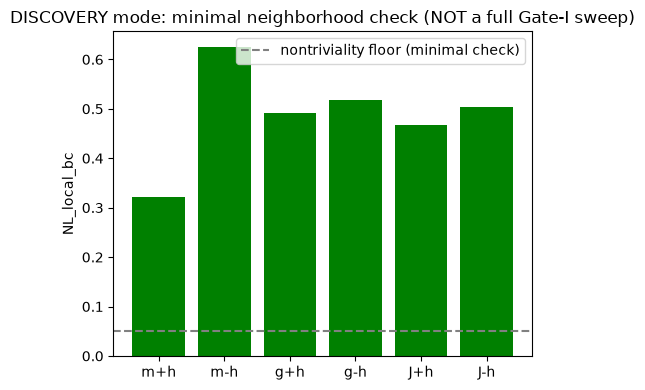

In [14]:
neighborhood_pass = []
for name, (val_M, val_NL, _, _) in [('m+h', plus_m), ('m-h', minus_m), ('g+h', plus_g), ('g-h', minus_g),
                                      ('J+h', plus_J), ('J-h', minus_J)]:
    ok = val_NL >= 0.05  # a minimal nontriviality check at each neighbor -- NOT a full gate re-evaluation
    neighborhood_pass.append({'offset': name, 'M_bc': val_M, 'NL_local_bc': val_NL, 'nontrivial': ok})
    print(f"{name}: M_bc={val_M:.3f} NL_local_bc={val_NL:.3f} nontrivial={ok}")
n_neigh_pass = sum(1 for n in neighborhood_pass if n['nontrivial'])
record('phase11b_neighborhood', neighborhood_pass)
print(f"\n{n_neigh_pass}/{len(neighborhood_pass)} neighboring points show nontrivial NL_local_bc.")
print("NEIGHBORHOOD ROBUSTNESS GATE (I): NOT EVALUABLE at full density -- only 6 one-axis-at-a-time "
      "points were checked, not a genuine cube/region sweep.")

fig, ax = plt.subplots(figsize=(5, 4))
colors_n = ['green' if n['nontrivial'] else 'red' for n in neighborhood_pass]
ax.bar([n['offset'] for n in neighborhood_pass], [n['NL_local_bc'] for n in neighborhood_pass], color=colors_n)
ax.axhline(0.05, color='gray', ls='--', label='nontriviality floor (minimal check)')
ax.set_ylabel('NL_local_bc'); ax.legend()
ax.set_title(f'{RUN_MODE} mode: minimal neighborhood check (NOT a full Gate-I sweep)')
fig.tight_layout()
savefig(fig, 'neighborhood_pass_fail_map')
plt.show()
manifest_entry('12_neighborhood_pass_fail_map', 'phase11b_neighborhood', 'Minimal one-axis-at-a-time neighborhood nontriviality check')

## Acceptance gates -- PASS / FAIL / NOT EVALUABLE

A_numerical_validity: {'ceiling_contaminated': False, 'n_valid_of_sampled': '4/16', 'result': 'PASS'}
B_derivative_stability: {'result': 'NOT EVALUABLE', 'reason': 'only 1 step size per axis this pass'}
C_memory_selectivity: {'R_memory': 0.9850194273453614, 'result': 'FAIL'}
D_local_NL_selectivity: {'R_NL_local': 0.1514992808436736, 'result': 'FAIL'}
E_response_geometry: {'alpha_deg': 177.15327776196494, 'result': 'FAIL'}
F_nontrivial_processing: {'NL_local_value': 0.470209782761445, 'result': 'PASS'}
G_low_backaction: {'D_M_mean': 0.03201529215537693, 'threshold': 0.1, 'result': 'PASS'}
H_seed_robustness: {'result': 'NOT EVALUABLE', 'reason': 'only 2 reservoir seed(s) run, need >=5'}
I_neighborhood_robustness: {'result': 'NOT EVALUABLE', 'reason': 'only a 6-point one-axis-at-a-time check ran, not a full sweep'}

3 PASS, 3 FAIL, 3 NOT EVALUABLE (out of 9 gates).


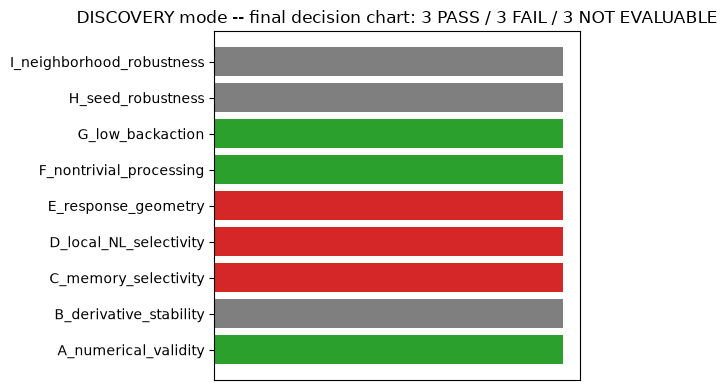

In [15]:
gates = {}
gates['A_numerical_validity'] = {
    'ceiling_contaminated': bool(discovery.all_results[0].ceiling_contaminated) if discovery.all_results else None,
    'n_valid_of_sampled': f"{discovery.n_valid}/{discovery.n_sampled}",
    'result': 'PASS' if CANDIDATE_HAS_VALID_REGION else 'FAIL',
}
gates['B_derivative_stability'] = {'result': 'NOT EVALUABLE', 'reason': 'only 1 step size per axis this pass'}
gates['C_memory_selectivity'] = {'R_memory': float(R_memory), 'result': 'PASS' if R_memory > 2 else 'FAIL'}
gates['D_local_NL_selectivity'] = {'R_NL_local': float(R_NL_local), 'result': 'PASS' if R_NL_local > 2 else 'FAIL'}
if np.isnan(alpha):
    gates['E_response_geometry'] = {'result': 'NOT EVALUABLE', 'reason': 'near-zero output scale on at least one axis'}
else:
    gates['E_response_geometry'] = {'alpha_deg': alpha, 'result': 'PASS' if 70 <= alpha <= 110 else 'FAIL'}
gates['F_nontrivial_processing'] = {'NL_local_value': response['NL_local']['value'],
                                     'result': 'PASS' if response['NL_local']['value'] > 0.1 else 'FAIL'}
gates['G_low_backaction'] = {'D_M_mean': traj.mean_trace_distance, 'threshold': 0.1,
                              'result': 'PASS' if traj.mean_trace_distance < 0.1 else 'FAIL'}
gates['H_seed_robustness'] = {'result': 'NOT EVALUABLE',
                               'reason': f"only {MODE_CFG['n_confirm_reservoir']} reservoir seed(s) run, need >=5"}
gates['I_neighborhood_robustness'] = {'result': 'NOT EVALUABLE',
                                       'reason': 'only a 6-point one-axis-at-a-time check ran, not a full sweep'}

for name, g in gates.items():
    print(f"{name}: {g}")
record('gates', gates)

n_pass = sum(1 for g in gates.values() if g.get('result') == 'PASS')
n_fail = sum(1 for g in gates.values() if g.get('result') == 'FAIL')
n_ne = sum(1 for g in gates.values() if g.get('result') == 'NOT EVALUABLE')
print(f"\n{n_pass} PASS, {n_fail} FAIL, {n_ne} NOT EVALUABLE (out of {len(gates)} gates).")

fig, ax = plt.subplots(figsize=(6, 4))
names_g = list(gates.keys())
colors_g = {'PASS': 'tab:green', 'FAIL': 'tab:red', 'NOT EVALUABLE': 'tab:gray'}
vals_g = [colors_g[gates[n]['result']] for n in names_g]
ax.barh(names_g, [1] * len(names_g), color=vals_g)
ax.set_xticks([])
ax.set_title(f'{RUN_MODE} mode -- final decision chart: {n_pass} PASS / {n_fail} FAIL / {n_ne} NOT EVALUABLE')
fig.tight_layout()
savefig(fig, 'final_decision_chart')
plt.show()
manifest_entry('13_final_decision_chart', 'gates', 'Per-gate PASS/FAIL/NOT EVALUABLE summary')

## Save results

In [16]:
config_path = os.path.join(RESULTS_DIR, 'validation_v2_1_config.json')
with open(config_path, 'w') as f:
    _json.dump({'RUN_MODE': RUN_MODE, 'MODE_CFG': MODE_CFG, 'provenance': provenance,
                'THETA_STAR': THETA_STAR, 'PHI_STAR': PHI_STAR, 'N_M': N_M, 'N_P': N_P, 'H_TILDE': H_TILDE,
                'control_ranges': {'m': [M_RANGE.p_min, M_RANGE.p_max], 'g': [G_RANGE.p_min, G_RANGE.p_max],
                                    'J': [J_RANGE.p_min, J_RANGE.p_max]}}, f, indent=2, default=str)
print(f"wrote {config_path}")

results_path = os.path.join(RESULTS_DIR, 'validation_v2_1_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"wrote {results_path}")

manifest_path = os.path.join(RESULTS_DIR, 'figure_manifest.json')
with open(manifest_path, 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)
print(f"wrote {manifest_path}")
for k in _all_results:
    print(' -', k)

wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_1\validation_v2_1_config.json
wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_1\validation_v2_1_results.json
wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2_1\figure_manifest.json
 - provenance
 - control_ranges
 - phase1_causal_latency
 - phase1_circuit_timing_table
 - exact_v1_reproduction
 - v21_reevaluation_same_point
 - phase3_feature_groups
 - phase3_budget_scan
 - phase4_discovery_table
 - phase4_selected_candidate
 - phase5_chaos_summary
 - phase6_response_dimensionless
 - phase7_decoupling_metrics
 - phase8_reset_response
 - phase9_timescales
 - phase10_backaction_trajectory
 - phase11_confirmation_smoke_test
 - phase11b_neighborhood
 - gates
